# NLP-Based Customer Query Intent Classification and Automatic Routing

### Mini Project using CLINC150 Dataset

**Objective:**  
To develop an NLP-based system that automatically identifies the intent of a customer's query and routes the query to the appropriate support service.

**NLP Technique:** TF-IDF

**Machine Learning Models:**
- Logistic Regression
- Multinomial Naive Bayes

**Evaluation Metrics:**
- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

## 1. Project Overview

Customer support systems receive a large number of text-based queries every day.
Manually identifying the purpose of each query can be time-consuming.

This project uses Natural Language Processing (NLP) and machine learning to automatically classify customer queries into predefined intent categories.

The system first preprocesses the text, converts it into numerical features using TF-IDF, and then uses machine learning models to predict the customer's intent.

The predicted intent is finally mapped to an appropriate support service.

## 2. Import Required Libraries

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## 3. Dataset Loading

In [2]:
from google.colab import files

uploaded = files.upload()

Saving data_full.json to data_full.json


In [3]:

with open("data_full.json", "r") as file:
    data = json.load(file)

print(data.keys())

dict_keys(['oos_val', 'val', 'train', 'oos_test', 'test', 'oos_train'])


### Create DataFrames

In [4]:
train_df = pd.DataFrame(
    data["train"],
    columns=["text", "intent"]
)

val_df = pd.DataFrame(
    data["val"],
    columns=["text", "intent"]
)

test_df = pd.DataFrame(
    data["test"],
    columns=["text", "intent"]
)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Testing samples:", len(test_df))

Training samples: 15000
Validation samples: 3000
Testing samples: 4500


## 4. Dataset Exploration

In [5]:
print("Sample training data:")
train_df.head()

Sample training data:


,text,intent
0,what expression would i use to say i love you ...,translate
1,can you tell me how to say 'i do not speak muc...,translate
2,"what is the equivalent of, 'life is good' in f...",translate
3,"tell me how to say, 'it is a beautiful morning...",translate
4,"if i were mongolian, how would i say that i am...",translate


In [6]:
intents = sorted(train_df["intent"].unique())

print("Number of intents:", len(intents))

print("\nAll available intents:")

for i, intent in enumerate(intents, 1):
    print(i, intent)

Number of intents: 150

All available intents:
1 accept_reservations
2 account_blocked
3 alarm
4 application_status
5 apr
6 are_you_a_bot
7 balance
8 bill_balance
9 bill_due
10 book_flight
11 book_hotel
12 calculator
13 calendar
14 calendar_update
15 calories
16 cancel
17 cancel_reservation
18 car_rental
19 card_declined
20 carry_on
21 change_accent
22 change_ai_name
23 change_language
24 change_speed
25 change_user_name
26 change_volume
27 confirm_reservation
28 cook_time
29 credit_limit
30 credit_limit_change
31 credit_score
32 current_location
33 damaged_card
34 date
35 definition
36 direct_deposit
37 directions
38 distance
39 do_you_have_pets
40 exchange_rate
41 expiration_date
42 find_phone
43 flight_status
44 flip_coin
45 food_last
46 freeze_account
47 fun_fact
48 gas
49 gas_type
50 goodbye
51 greeting
52 how_busy
53 how_old_are_you
54 improve_credit_score
55 income
56 ingredient_substitution
57 ingredients_list
58 insurance
59 insurance_change
60 interest_rate
61 international_f

In [7]:
intent_counts = train_df["intent"].value_counts()

print("Number of examples for each intent:")
print(intent_counts)

Number of examples for each intent:
intent
translate          100
transfer           100
timer              100
definition         100
meaning_of_life    100
                  ... 
income             100
order              100
traffic            100
order_checks       100
card_declined      100
Name: count, Length: 150, dtype: int64


## 5. Intent Selection

In [8]:
selected_intents = [
    "book_flight",
    "book_hotel",
    "flight_status",
    "lost_luggage",
    "restaurant_reservation",
    "restaurant_suggestion",
    "weather",
    "car_rental",
    "travel_suggestion",
    "directions"
]

print("Selected intents:")

for i, intent in enumerate(selected_intents, 1):
    print(i, intent)

Selected intents:
1 book_flight
2 book_hotel
3 flight_status
4 lost_luggage
5 restaurant_reservation
6 restaurant_suggestion
7 weather
8 car_rental
9 travel_suggestion
10 directions


### Why these intents?

Ten travel and customer-assistance intents were selected from CLINC150 to create a focused and manageable multi-class NLP classification problem.

The selected intents cover flight booking, hotel booking, flight status, baggage problems, restaurants, weather, transportation, travel planning, and navigation.

## 6. Dataset Preparation

In [9]:
train_selected = train_df[
    train_df["intent"].isin(selected_intents)
].copy()

print("Training samples:", len(train_selected))
print("\nTraining class distribution:")
print(train_selected["intent"].value_counts())

Training samples: 1000

Training class distribution:
intent
flight_status             100
restaurant_reservation    100
restaurant_suggestion     100
lost_luggage              100
travel_suggestion         100
book_hotel                100
weather                   100
directions                100
book_flight               100
car_rental                100
Name: count, dtype: int64


In [10]:
val_selected = val_df[
    val_df["intent"].isin(selected_intents)
].copy()

print("Validation samples:", len(val_selected))
print("\nValidation class distribution:")
print(val_selected["intent"].value_counts())

Validation samples: 200

Validation class distribution:
intent
flight_status             20
restaurant_reservation    20
restaurant_suggestion     20
lost_luggage              20
travel_suggestion         20
book_hotel                20
weather                   20
directions                20
book_flight               20
car_rental                20
Name: count, dtype: int64


In [11]:
test_selected = test_df[
    test_df["intent"].isin(selected_intents)
].copy()

print("Test samples:", len(test_selected))
print("\nTest class distribution:")
print(test_selected["intent"].value_counts())

Test samples: 300

Test class distribution:
intent
flight_status             30
restaurant_reservation    30
restaurant_suggestion     30
lost_luggage              30
travel_suggestion         30
book_hotel                30
weather                   30
directions                30
book_flight               30
car_rental                30
Name: count, dtype: int64


### Separate Input and Target Variables

In [12]:
X_train = train_selected["text"]
y_train = train_selected["intent"]

X_val = val_selected["text"]
y_val = val_selected["intent"]

X_test = test_selected["text"]
y_test = test_selected["intent"]

print("Training text:", X_train.shape)
print("Training labels:", y_train.shape)

print("Testing text:", X_test.shape)
print("Testing labels:", y_test.shape)

Training text: (1000,)
Training labels: (1000,)
Testing text: (300,)
Testing labels: (300,)


## 7. Text Preprocessing

In [13]:
import re

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [14]:
example = "I WANT to BOOK a Flight!!! Can you help me?"

print("Original:")
print(example)

print("\nAfter preprocessing:")
print(preprocess_text(example))

Original:
I WANT to BOOK a Flight!!! Can you help me?

After preprocessing:
i want to book a flight can you help me


In [15]:
X_train_clean = X_train.apply(preprocess_text)
X_val_clean = X_val.apply(preprocess_text)
X_test_clean = X_test.apply(preprocess_text)

print("\nOriginal dataset example:")
print(X_train.iloc[0])

print("\nAfter preprocessing:")
print(X_train_clean.iloc[0])


Original dataset example:
what is the projected time frame for the flight to land

After preprocessing:
what is the projected time frame for the flight to land


## 8. TF-IDF Feature Extraction

In [16]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train_clean)
X_val_tfidf = vectorizer.transform(X_val_clean)
X_test_tfidf = vectorizer.transform(X_test_clean)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (1000, 4307)
Validation TF-IDF shape: (200, 4307)
Testing TF-IDF shape: (300, 4307)


TF-IDF converts the cleaned customer queries into numerical feature vectors that can be processed by machine learning algorithms.

The vectorizer is fitted only on the training data and then used to transform the validation and test data.

## 9. Model 1 — Logistic Regression

In [17]:
logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [18]:
y_pred_lr = logistic_model.predict(X_test_tfidf)

print("First 10 predictions:")
print(y_pred_lr[:10])

First 10 predictions:
['flight_status' 'flight_status' 'flight_status' 'flight_status'
 'flight_status' 'flight_status' 'flight_status' 'flight_status'
 'flight_status' 'flight_status']


In [19]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print(
    "Logistic Regression Accuracy:",
    round(lr_accuracy * 100, 2),
    "%"
)

Logistic Regression Accuracy: 97.33 %


In [20]:
print("Logistic Regression Classification Report")

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=selected_intents
    )
)

Logistic Regression Classification Report
                        precision    recall  f1-score   support

           book_flight       0.97      1.00      0.98        30
            book_hotel       0.94      0.97      0.95        30
         flight_status       1.00      0.93      0.97        30
          lost_luggage       1.00      1.00      1.00        30
restaurant_reservation       1.00      1.00      1.00        30
 restaurant_suggestion       1.00      1.00      1.00        30
               weather       0.97      0.93      0.95        30
            car_rental       0.90      0.93      0.92        30
     travel_suggestion       1.00      0.97      0.98        30
            directions       0.97      1.00      0.98        30

              accuracy                           0.97       300
             macro avg       0.97      0.97      0.97       300
          weighted avg       0.97      0.97      0.97       300



## 10. Model 2 — Multinomial Naive Bayes

In [21]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [22]:
y_pred_nb = nb_model.predict(X_test_tfidf)

print("First 10 Naive Bayes predictions:")
print(y_pred_nb[:10])

First 10 Naive Bayes predictions:
['flight_status' 'flight_status' 'flight_status' 'flight_status'
 'flight_status' 'flight_status' 'flight_status' 'flight_status'
 'flight_status' 'flight_status']


In [23]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print(
    "Naive Bayes Accuracy:",
    round(nb_accuracy * 100, 2),
    "%"
)

Naive Bayes Accuracy: 97.0 %


In [24]:
print("Naive Bayes Classification Report")

print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=selected_intents
    )
)

Naive Bayes Classification Report
                        precision    recall  f1-score   support

           book_flight       1.00      1.00      1.00        30
            book_hotel       0.94      0.97      0.95        30
         flight_status       0.96      0.90      0.93        30
          lost_luggage       1.00      1.00      1.00        30
restaurant_reservation       1.00      1.00      1.00        30
 restaurant_suggestion       1.00      1.00      1.00        30
               weather       0.94      0.97      0.95        30
            car_rental       0.93      0.93      0.93        30
     travel_suggestion       1.00      0.93      0.97        30
            directions       0.94      1.00      0.97        30

              accuracy                           0.97       300
             macro avg       0.97      0.97      0.97       300
          weighted avg       0.97      0.97      0.97       300



## 11. Model Comparison

In [25]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes"
    ],
    "Accuracy (%)": [
        lr_accuracy * 100,
        nb_accuracy * 100
    ]
})

results

,Model,Accuracy (%)
0,Logistic Regression,97.333333
1,Multinomial Naive Bayes,97.000000


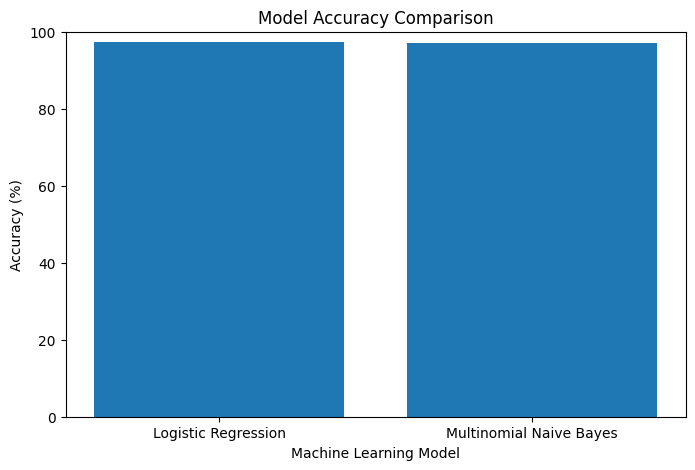

In [26]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["Accuracy (%)"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

plt.show()

## 12. Confusion Matrix

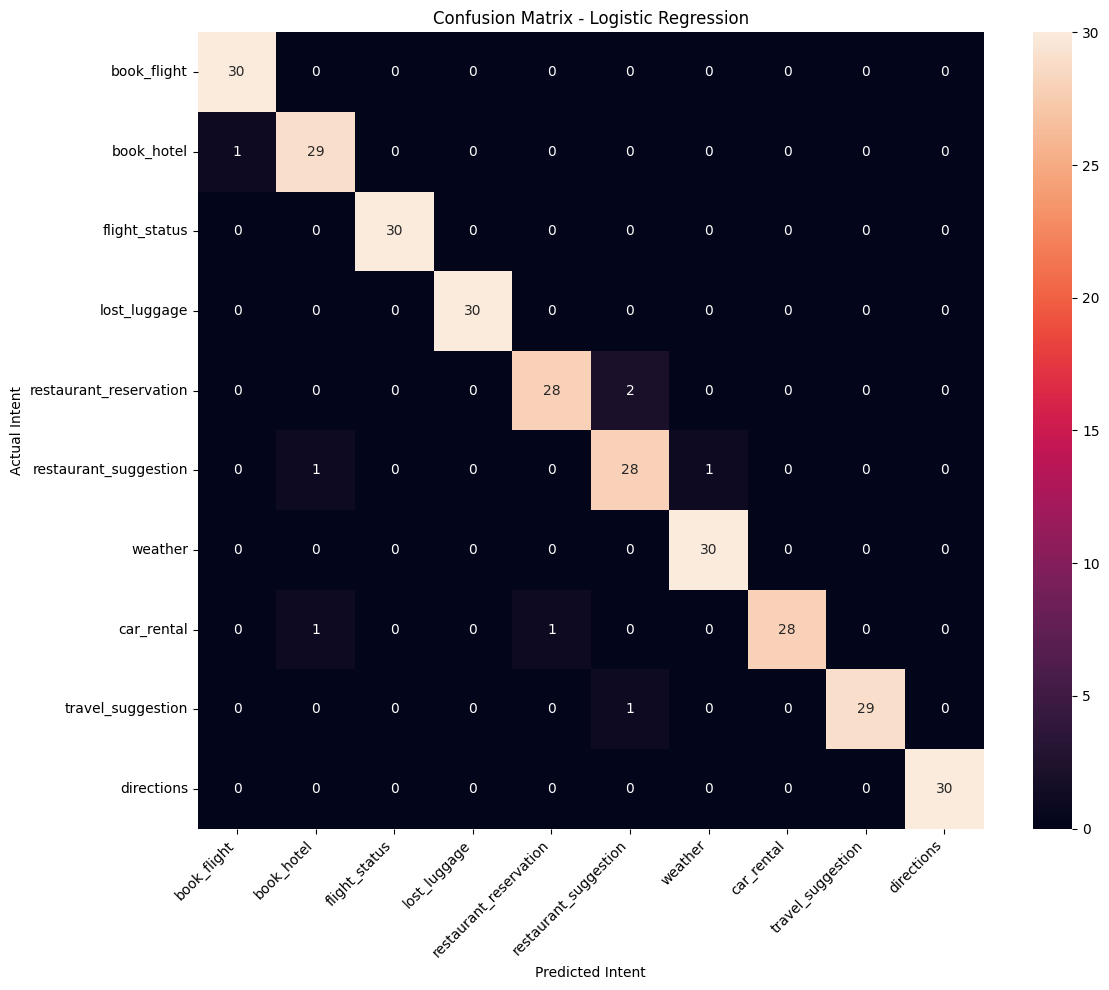

In [27]:
cm = confusion_matrix(
    y_test,
    y_pred_lr,
    labels=selected_intents
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=selected_intents,
    yticklabels=selected_intents
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Intent")
plt.ylabel("Actual Intent")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 13. Custom Customer Query Prediction

In [28]:
def predict_intent(query):

    # Preprocess the query
    cleaned_query = preprocess_text(query)

    # Convert the query into TF-IDF features
    query_tfidf = vectorizer.transform([cleaned_query])

    # Predict the intent
    prediction = logistic_model.predict(query_tfidf)[0]

    return prediction

In [29]:
# Test with a new customer query

query = "I want to book a flight to Delhi"

predicted_intent = predict_intent(query)

print("Customer Query:", query)
print("Predicted Intent:", predicted_intent)

Customer Query: I want to book a flight to Delhi
Predicted Intent: book_flight


## 14. Automatic Query Routing

In [30]:

routing_map = {
    "book_flight": "Flight Booking Support",
    "book_hotel": "Hotel Booking Support",
    "flight_status": "Flight Status Support",
    "lost_luggage": "Baggage Support",
    "restaurant_reservation": "Restaurant Reservation Support",
    "restaurant_suggestion": "Restaurant Recommendation Service",
    "weather": "Weather Information Service",
    "car_rental": "Car Rental Support",
    "travel_suggestion": "Travel Planning Support",
    "directions": "Navigation Support"
}

In [31]:
# Complete query classification and routing

def classify_and_route(query):

    predicted_intent = predict_intent(query)

    department = routing_map[predicted_intent]

    print("Customer Query:", query)
    print("Predicted Intent:", predicted_intent)
    print("Suggested Route:", department)

In [32]:
# Test the complete system

classify_and_route("My luggage is missing after my flight")

Customer Query: My luggage is missing after my flight
Predicted Intent: lost_luggage
Suggested Route: Baggage Support


## 15. Final System Demonstration

In [33]:
# Test multiple customer queries

test_queries = [
    "I need to book a flight",
    "Can you help me reserve a hotel?",
    "Is my flight delayed?",
    "My luggage is missing",
    "I want to reserve a table at a restaurant",
    "Can you suggest a good restaurant?",
    "What is the weather today?",
    "I need to rent a car",
    "Suggest a good place to travel",
    "How do I get to the airport?"
]

for query in test_queries:
    classify_and_route(query)
    print("-" * 50)

Customer Query: I need to book a flight
Predicted Intent: book_flight
Suggested Route: Flight Booking Support
--------------------------------------------------
Customer Query: Can you help me reserve a hotel?
Predicted Intent: book_hotel
Suggested Route: Hotel Booking Support
--------------------------------------------------
Customer Query: Is my flight delayed?
Predicted Intent: flight_status
Suggested Route: Flight Status Support
--------------------------------------------------
Customer Query: My luggage is missing
Predicted Intent: lost_luggage
Suggested Route: Baggage Support
--------------------------------------------------
Customer Query: I want to reserve a table at a restaurant
Predicted Intent: restaurant_reservation
Suggested Route: Restaurant Reservation Support
--------------------------------------------------
Customer Query: Can you suggest a good restaurant?
Predicted Intent: restaurant_suggestion
Suggested Route: Restaurant Recommendation Service
------------------

## 16. Conclusion

This project demonstrates how Natural Language Processing can be used to automatically classify customer queries into predefined intent categories.

The system uses text preprocessing and TF-IDF feature extraction followed by Logistic Regression and Multinomial Naive Bayes classification.

The models are evaluated using accuracy, precision, recall, F1-score, and a confusion matrix.

The final system also demonstrates automatic routing of customer queries to the appropriate support service based on the predicted intent.